In [2]:
import requests
from IPython.core.display import HTML
#HTML(f"""
#<style>
#@import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
#</style>
#""")

### Q9 Exercise Week 11 (Evaluation)

#### (a) Metrics/Evaluation of Classifiers
- confusion matrix (Task 3)
- Different metrics for classification evaluation (Task 5)
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - Specificity (true negative rate)
    - MCC (Matthews correlation coefficient)
        - Formula:
            -    $MCC=\frac{TP \cdot TN-FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$
        - Score range: -1 to +1
        - Interpretation: 
            - +1 -> perfect prediction, 
            - 0 -> random prediction, 
            - -1 -> total disagreement between prediction and observation
    - ROC curve and Precision-Recall curve
        - AUC (Area Under the Curve) for ROC and Precision-Recall curves
        - Optimal threshold based on ROC curve

#### (b) Metrics/Evaluation of Regression (Since there is no you may use assignment 1 and week 13/14 as part of your sescription)
- MAE (Mean Absolute Error)
- SSD (Sum of Squared Differences)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- Regression metrics for evaluation of gaze estimation model performance (W06 02) 
    - RMSE on both x and y coordinates
    - MAE for x and y coordinates separately
    - Euclidean distance error: Average Euclidean distance between predicted and actual gaze positions.
- Evaluation of Neural Networks (W14 01)
    - Training and validation loss curves (Overfitting and underfitting detection)
    - Absolute error for x and y coordinates
    - MSE for model performance comparison

#### (c) Imbalanced data for classification and regression
- Class imbalance problem 
    - classification
    - regression
- Techniques to handle imbalanced data in classification
    - Oversampling
    - Undersampling
    - Data augmentation
    - selection of suitable evaluation metrics (and ROC curve vs precision-recall curve)
- Techniques to handle imbalanced data in regression
    - missing data (W09 03)

# Evaluating Classifiers

**Overview**
This exercise is about evaluation metrics for binary classification. 
The main focus is to evaluate a classification model, irrespective of which model (linear or non-linear) is being used.

Recall that the confusion matrix for binary classification problems has the following structure:

$$
\begin{array}{cc|c|c|}
  & & \text{Predicted Negative} & \text{Predicted Positive} \\
\hline
\text{Actual Negative} & & TN & FP \\
\hline
\text{Actual Positive} & & FN & TP \\
\end{array}
$$
- **TN** - True Negative
- **FN** - False Negative 
- **FP** - False positive
- **TP** - True Positive


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#import">Task 1: Generating Data</a>
            </li>
            <li>
            <a href="#First">Task 2: Training a random Classifier</a>
            </li>
            <li>
            <a href="#accuracy">Task 3: Model accuracy</a>
            </li>
            <li>
            <a href="#classif_report">Task 4: Evaluation</a>
            </li>
            <li>
            <a href="#svc_model">Task 5: Class Imbalance visualization reflection</a>
            </li>
            <li>
            <a href="#metrics">Task 6: ROC and Precision-Recall curves evaluati…</a>
            </li>
        </ul>
    </div>
</article>

## Generating Data

---
**Task 1 (easy): Generating Data👩‍💻**
1. Run the cell below to generate a dataset comprising of 500 samples, 20 features, and 2 classes. This dataset is partitioned using an 80-20 train-test split.


---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve, auc, average_precision_score, roc_curve
import classifier_util

import warnings
warnings.filterwarnings("ignore")


X,Y  = datasets.make_classification(n_samples=500, n_features=20, n_classes=2, random_state=1)
print('Dataset Size : ',X.shape,Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.80, test_size=0.20, stratify=Y, random_state=1)
print('Train/Test Size : ', X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

Dataset Size :  (500, 20) (500,)
Train/Test Size :  (400, 20) (100, 20) (400,) (100,)


## Performance Metrics
In the following task you will evaluate the model's performance on the test data using different metrics. 

---
**Task 2 (easy): Training a random Classifier👩‍💻**
1. Run the cell below to train a random Classifier.


---

In [4]:
classifier1 = classifier_util.RandomClassifier(random_state=1, C=0.1)
classifier1.fit(X_train, Y_train)


---
**Task 3 (easy): Model accuracy👩‍💻**
Classification accuracy is given by 
$$ \text{accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}$$
 
Run the following cell to make predictions using the `RandomClassifier`
 on the test and training sets. Calculate accuracy by comparing predictions to actual labels: 
1. Calculate model accuracy on the training set.
2. Calculate model accuracy on the test set.
3. Run the cell below to construct and plot the confusion matrix of the model predictions on the training set. 
4. Construct and plot the confusion matrix of the model predictions on the test set. 


---

Training Accuracy: 0.9525
Test Accuracy: 0.93


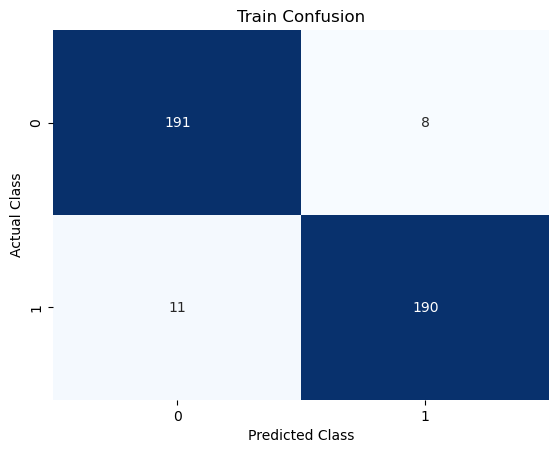

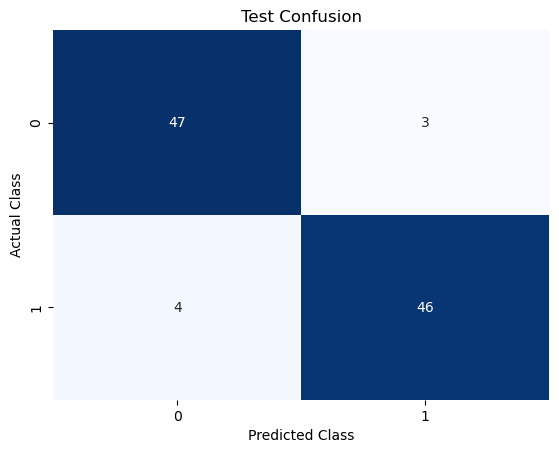

In [5]:
Y_preds = classifier1.predict(X_test)
Y_preds2 = classifier1.predict(X_train)

# Calculate accuracy here ... 
accuracy_train = (np.sum(Y_preds2 == Y_train)) / len(Y_train) 
accuracy_test = (np.sum(Y_preds == Y_test)) / len(Y_test)
# In Confusion matrix: ( TP + TN ) / (TP + TN + FP + FN)
#Using accuracy_score from sklearn:
#accuracy_train = accuracy_score(Y_train, Y_preds2)
#accuracy_test = accuracy_score(Y_test, Y_preds)
print("Training Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)

conf_mat_train = confusion_matrix(Y_train, Y_preds2)
sns.heatmap(conf_mat_train, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Train Confusion')
plt.show()

conf_mat_test = confusion_matrix(Y_test, Y_preds)
sns.heatmap(conf_mat_test, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Test Confusion')
plt.show()

**Performance metrics**

**Recall from the lecture**
Performance metrics such as **precision**, **recall**, **F$_1$-score**, **specificity** and **Matthews Correlation Coefficient (MCC)**  provide different views of the performance of the classifier.
- **Precision** - or positive predictive value, represents how many predictions of the positive class actually belong to that class. 

$$
\frac{𝑇𝑃}{𝑇𝑃+𝐹𝑃}
$$


- **Recall** -  also known as sensitivity, true positive rate, or hit rate assesses whether the classifier correctly identifies positive instances out of the total actual postive instances. 

$$
\frac{𝑇𝑃}{𝑇𝑃+𝐹𝑁} 
$$


- **F$_1$-score** - harmonic mean of precision & recall. 

$$
2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision}+\text{Recall}} 
$$


- **Specificity** - also known as the true negative rate, is the percentage of correctly predicted instances of the negative class. 

$$
\frac{TN}{TN+FP} 
$$


- **Matthews Correlation Coefficient (MCC)** - also known as the phi coefficient, is a correlation-based metric that measures the quality of binary classifications, even with imbalanced classes.

$$ 
MCC=\frac{TP \cdot TN-FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$





---
**Task 4 (easy): Performance metrics👩‍💻**
1. Use the confusion matrix of the test data from [Task 3](#accuracy) to find and store the true positive, false positive, true negative and false negative values. 

2. In the cell below calculate the following evaluation metrics for the classification model:
    - Precision
    - Recall
    - F1-score
    - Specificity
    - MCC




---

In [6]:
# write your solution here
TP = conf_mat_test[1,1]
FP = conf_mat_test[0,1]
TN = conf_mat_test[0,0]
FN = conf_mat_test[1,0]

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)
print("----------------------")

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = TN / (TN + FP)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Specificity:", specificity)
print("Matthews Correlation Coefficient (MCC):", mcc)

TP: 46
FP: 3
TN: 47
FN: 4
----------------------
Precision: 0.9387755102040817
Recall: 0.92
F1 Score: 0.9292929292929293
Specificity: 0.94
Matthews Correlation Coefficient (MCC): 0.8601720516172061



---
**Task 5 (easy): Evaluation💡📽️**
1. Inspect the metrics and reflect on how they individually help in understanding and evaluating the performance of a classification model?
2. How does the MCC help you assess the performance of the models?


---

In [7]:
# Write your reflections here...
#1 Inspect the metrics and reflect on how they individually help in understanding and evaluating the performance of a classification model?
# Accuracy (of test data): 0.93
    # (TP + TN) / (TP + TN + FP + FN)
    #The accuracy metric tells us that 93% of the model's predictions on the test data are correct.
    #However, accuracy can be misleading, especially in imbalanced datasets where the bigger class would dominate the accuracy score.
    #In such cases, a model could achieve high accuracy by simply predicting the majority class, while failing to identify the minority class effectively.
    #E.g. A model might just predict all instances as the majority class and still achieve high accuracy, even if it failed on all instances of the minority class.

    # Example of problematic confusion matrix:
    # A case with 100 instances in total, and only 5 of them are positive
    # Model predicts all as negative.
    # Then the confusion matrix would be:
    #                Predicted
    #            |   Neg  |  Pos
    #          ---------------------
    #        Neg |   95   |   0
    # Actual ---------------------
    #        Pos |    5   |   0
    # In this case, accuracy = (95 + 0) / 100 = 0.95 (95%)
    # But the model failed to identify any positive instances.


# Precision: 0.94
    # TP / (TP + FP)
    # The precision metric indicates that when the model predicts a positive class, it is correct 94% of the time.
    # Precision is crucial in scenarios where the cost of false positives is high (Where we want maximize true positives and minimize false positives).
    # E.g. In spam detection, where a false positive means a legitimate email is marked as spam. 
    # Or in medical diagnosis, where a false positive could lead to unnecessary treatments.
    # Problem: A model which only classify one instance as positive - and do this correctly - but all other as negative, would get a perfect precision of 1.0.

    # Example of problematic confusion matrix:
    # A case with 100 instances in total, and 100 of them are positive
    # Model predicts only 1 instance as positive, and it is correct.
    # Then the confusion matrix would be:
    #                Predicted
    #            |   Neg  |  Pos
    #          ---------------------
    #        Neg |   0    |   0
    # Actual ---------------------
    #        Pos |   95   |   5
    # In this case, precision = 5 / (5 + 0) = 1.0 (100%)
    # But the model failed to identify 95 other positive instances.

# Recall: 0.92
    # TP / (TP + FN)
    # The recall metric shows that the model correctly identifies 92% of all actual positive cases.
    # Recall is important in situations where the cost of false negatives is high (Where we want to maximize true positives and minimize false negatives).
    # E.g. In disease screening, where missing a positive case (false negative) could make doctors overlook a patient who needs treatment.
    # Or in fraud detection, where failing to identify fraudulent transactions could lead to significant financial losses.
    # Problem: A model which classifies all instances as positive would get a perfect recall of 1.0.

    # Example of problematic confusion matrix:
    # A case with 100 instances in total, and 1 of them are positive
    # Model predicts all as positive.
    # Then the confusion matrix would be:
    #                Predicted
    #            |   Neg  |  Pos
    #          ---------------------
    #        Neg |   0    |   95
    # Actual ---------------------
    #        Pos |   0    |   5
    # In this case, recall = 5 / (5 + 0) = 1.0 (100%)
    # But the model incorrectly classified 95 negative instances as positive.

# F1 Score: 0.93
    # 2 * (Precision * Recall) / (Precision + Recall)
    # The F1 score is the harmonic mean of precision and recall, providing a single metric that balances both concerns.
    # In this case, an F1 score of 0.93 indicates that the model performs well in both precision and recall (As we also saw when calculating them separately).
    # It is particularly useful when we need to find a balance between precision and recall, especially in imbalanced datasets.
    # E.g. In search engines, where both false positives (irrelevant results) and false negatives (missing relevant results) can impact user satisfaction.
    # Problem: Does not take true negatives into account.

    # Example of problematic confusion matrix:
    # two different cases with the same F1 score:
    # Case 1:
    #                Predicted
    #            |   Neg  |  Pos
    #          ---------------------
    #        Neg |    0   |   300
    # Actual ---------------------
    #        Pos |   300  |   400
    #
    # Case 2:
    #                Predicted
    #            |   Neg  |  Pos
    #          ---------------------
    #        Neg |   900  |   30
    # Actual ---------------------
    #        Pos |   30   |   40
    #
    # Recall: 40 / (40 + 30) = 0.57  for both cases
    # Precision: 40 / (40 + 30) = 0.57 for both cases
    # F1 score: 2 * (0.57 * 0.57) / (0.57 + 0.57) = 0.57 for both cases
    #
    # Accuracy for case 1: (0 + 400) / (0 + 400 + 300 + 300) = 0.40
    # Accuracy for case 2: (900 + 40) / (900 + 40 + 30 + 30) = 0.94
    #
    # Both cases would yield the same F1 score, but the secound case would have predicted a lot more negative cases correctly (the accuracy would be much higher for the second case).
    # (In contrast to the f1 score, the mcc metric would be higher for the second case than the first).

# Specificity: 0.94
    # TN / (TN + FP)
    # The specificity metric indicates that the model correctly identifies 94% of all actual negative cases.
    # Specificity is important in scenarios where it is crucial to correctly identify negative cases (Where we want to maximize true negatives and minimize false positives).
    # E.g. In medical testing, where a high specificity ensures that healthy individuals are not incorrectly diagnosed with a disease.
    # Or in quality control, where a high specificity ensures that non-defective products are not mistakenly classified as defective.
    # Problem: A model which classifies all instances as negative would get a perfect specificity of 1.0.

    # Example of problematic confusion matrix:
    # A case with 100 instances in total, and 5 of them are negative
    # Model predicts all as negative.
    # Then the confusion matrix would be:
    #                Predicted
    #            |   Neg  |  Pos
    #          ---------------------
    #        Neg |   5    |   0
    # Actual ---------------------
    #        Pos |   95   |   0
    # In this case, specificity = 5 / (5 + 0) = 1.0 (100%)
    # But the model incorrectly classified 95 positive instances as negative.

# Matthews Correlation Coefficient (MCC): 0.86
    # (TP * TN - FP * FN) / sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    # The MCC metric indicates a strong correlation between the predicted and actual classifications, with a value of 0.86.
    # MCC is particularly useful for evaluating binary classifiers, especially in imbalanced datasets, as it takes all four categories of the confusion matrix into account: true positives, true negatives, false positives, and false negatives.
    # Problem: MCC is not as straightforward to interpret as other metrics like accuracy, precision, or recall. It can be hard to understand what the reason behind a specific MCC value is. And it is very general, which might not be what we want, if we want to focus on specific aspects of the model's performance.


# 2 How does the MCC help you assess the performance of the models?
    # The MCC score ranges from -1 to +1. 1 means perfect prediction and -1 means total disagreement between prediction and actual case.
    # MCC consider all four outcomes in the confusion matrix (TP, TN, FP, FN), which gives a better overall picture of the model's performance.
    # MCC is particularly useful in imbalanced datasets, where traditional metrics like accuracy can be misleading.

## Imbalanced Classes
The cell below generates a dataset with 1,000 samples across 10 classes. Then an imbalanced dataset is created by combining 9 classes such that all samples in class 0 are marked as positive, while samples in the remaining classes are marked as negative. This results in a 10% positive and 90% negative distribution.


In [13]:
X, Y = datasets.make_classification(n_samples=1000, n_classes=10, n_informative=10)

# Mark the minority class as True
Y = (Y == 0).astype(int)

print('Dataset Size:', X.shape, Y.shape)

# Check the imbalance ratio
imbalance_ratio_actual = np.mean(Y)
print(f'Imbalance Ratio (Positive/Minority Class): {imbalance_ratio_actual:.2f}')

Dataset Size: (1000, 20) (1000,)
Imbalance Ratio (Positive/Minority Class): 0.10



---
**Task 6 (hard): Class Imbalance👩‍💻**
The following task will evaluate `classifier2`
 on the imbalanced dataset.
1. The cell below includes the classifier, variables to store performance metrics, and an incomplete for-loop that performs data splitting for 5-fold cross-validation. Complete the loop so that for each fold:    
   - Train a `classifier2` on the training folds. 
   - Predict labels on the validation folds.
   - Calculate the confusion matrix and the performance metrics on the validation sets (precision, recall, F1-Score, specificity, MCC). Print the average of each metric (use `np.nanmean()`
 as some of these metrics might inlcude NaNs). 




**Info**
In the cell below, the data is randomized before each split. This can lead to slight variations in model performance metrics and graphs, so different results can be expected with each run.


---

In [31]:
classifier2 = classifier_util.RandomClassifier2()

accuracies= []
accuracies, precisions, recalls, f1_scores, specificities, mccs = [], [], [], [], [], []

for train_idx_svc, test_idx_svc in KFold(n_splits=5, shuffle=True).split(X):
    X_train, X_test = X[train_idx_svc], X[test_idx_svc]
    Y_train, Y_test = Y[train_idx_svc], Y[test_idx_svc]

    # write your solution here
    classifier2.fit(X_train, Y_train)
    Y_preds = classifier2.predict(X_test)
    conf_mat = confusion_matrix(Y_test, Y_preds)
    TP, FP, TN, FN = conf_mat[1,1], conf_mat[0,1], conf_mat[0,0], conf_mat[1,0]
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) if (TP + FP) > 0 and (TP + FN) > 0 and (TN + FP) > 0 and (TN + FN) > 0 else np.nan

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1_score)
    specificities.append(specificity)
    mccs.append(mcc)

print("Average Accuracy:", np.nanmean(accuracies))
print("Average Precision:", np.nanmean(precisions))
print("Average Recall:", np.nanmean(recalls))
print("Average F1 Score:", np.nanmean(f1_scores))
print("Average Specificity:", np.nanmean(specificities))
print("Average MCC:", np.nanmean(mccs))


Average Accuracy: 0.922
Average Precision: 0.95
Average Recall: 0.21475274725274723
Average F1 Score: 0.33972370766488413
Average Specificity: 0.9989130434782609
Average MCC: 0.41798399361848737



---
**Task 7 (hard): Class Imbalance💡📽️**
The following task will evaluate `classifier2`
 on the imbalanced dataset.
1. Why do some of the metrics return NaNs?
2. Is the model able to reliably identify the minority class? 
3. What are the implications for the model's performance and its practical utility?
4. How does the MCC help you assess the performance of the models, especially regarding their ability to handle class imbalance? 


---

In [10]:
# Write your reflections here...
# 1 Why do some of the metrics return NaNs?
# Some of the metrics return NaNs because of division by zero errors that occur when the denominators in their calculations are zero.
# For example, precision is calculated as TP / (TP + FP). If there are no positive predictions (i.e., TP + FP = 0), this results in a division by zero, leading to a NaN value for precision.

# 2 Is the model able to reliably identify the miority class?
# The minority class is the positive class in this imbalanced dataset.
# The model struggles to identify the minority class reliably. 
# This is indicated by both the low recall, F1 score, and MCC values.
# The low recall suggests that the model is missing a significant number of actual positive cases (minority class instances).
# The low F1 score indicates that the balance between precision and recall is poor.
# The low MCC value indicates a weak correlation between the predicted and actual classifications, suggesting that the model's predictions are not much better than random guessing.

# 3 What are the implications for the model's performance and its practical utility?
# The model's poor performance in identifying the minority class has significant implications for its practical utility, especially in cases where correct detection of the minority class (positive) is very important.

# 4 How does the MCC help you assess the performance of the models, especially regarding their ability to handle class imbalance? 
# MCC consider all four outcomes in the confusion matrix (TP, TN, FP, FN), which gives a better overall picture of the model's performance.
# MCC is particularly useful in imbalanced datasets, as it evaluates the model's performance fairly even when the classes are not equally represented.
# A low MCC indicates that the model is not performing well in distinguishing the data, even though it might have a high accuracy due to the class imbalance.


---
**Task 8 (hard): Class Imbalance visualization👩‍💻**
1. Run the cell below to plot all the metrics in the same plot.


**Info**
In the cell below, the data is randomized before each split. This can lead to slight variations in model performance metrics and graphs, so different results can be expected with each run.


---

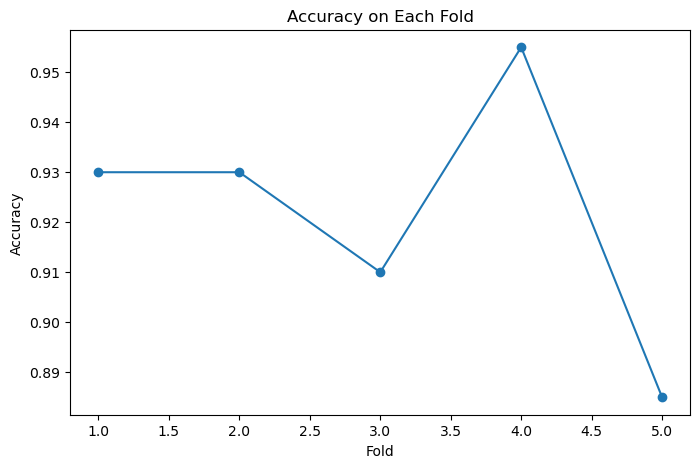

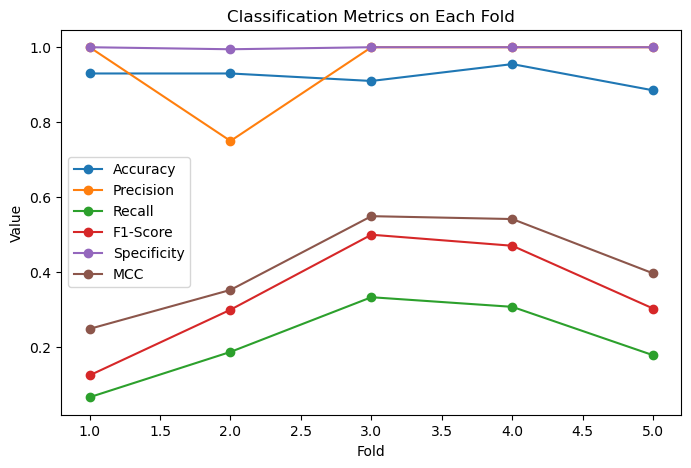

In [32]:
# Step 2
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), accuracies, marker='o')
plt.title('Accuracy on Each Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

# step 5
# Create a list of metric names for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'MCC']

# Create a list of the values for each metric
metric_values = [accuracies, precisions, recalls, f1_scores, specificities, mccs]

# Plot the metrics on the same plot
plt.figure(figsize=(8, 5))
for i, metric_values_list in enumerate(metric_values):
    plt.plot(range(1, 6), metric_values_list, marker='o', label=metrics[i])

plt.title('Classification Metrics on Each Fold')
plt.xlabel('Fold')
plt.ylabel('Value')
plt.legend()
plt.show()

# Each fold represents a different subset of the data used for testing during cross-validation.
# By plotting the metrics for each fold, we can observe how the model's performance varies across different subsets of the data.
# This helps us assess the model's stability and generalizability.


---
**Task 9 (hard): Class Imbalance visualization reflection💡**
1. Are certain metrics consistently lower? What might this indicate about the model’s handling of the imbalanced data?


---

In [0]:
# write your reflections here
# 1 Are certain metrics consistently lower? What might this indicate about the model’s handling of the imbalanced data?
# Yes, certain metrics such as Recall, F1-Score, and MCC are consistently lower across the folds.
# This indicates that the model is struggling to effectively identify the minority class (positive class) in the imbalanced dataset

## ROC Curves and Precision-Recall Curves
This task examines the ROC (Receiver Operating Characteristic) curve and the Precision-Recall curve for the classifier trained on the imbalanced dataset. The ROC curve illustrates the trade-off between true positive rate (sensitivity) and false positive rate, while the Precision-Recall curve shows the balance between precision and recall.

---
**Task 10 (medium): ROC and Precision-Recall curves👩‍💻💡**
The cell below divides the dataset (imbalanced) into a training and a test set. It also calculates both the ROC curve and the Precision-Recall curve and extracts relevant metrics such as: `fpr`
 (False Positive Rate), `tpr`
 (True Positive Rate or **recall**), and **precision**.
1. Run the cell below to plot the ROC curve and the Precision-Recall curve.


---

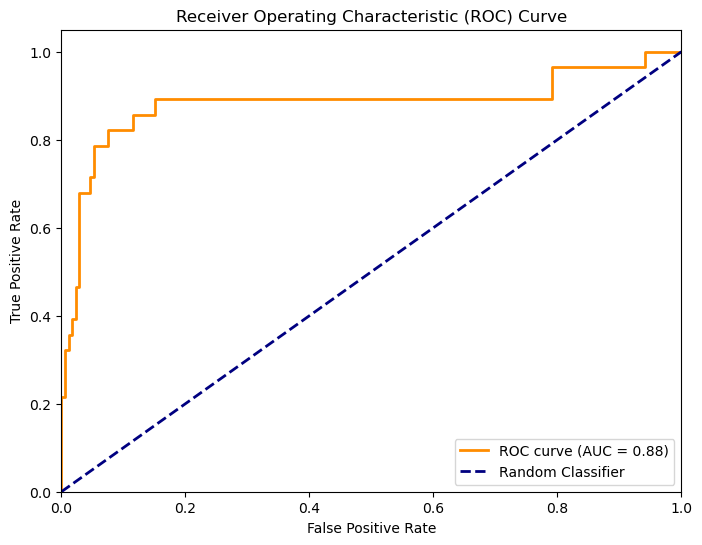

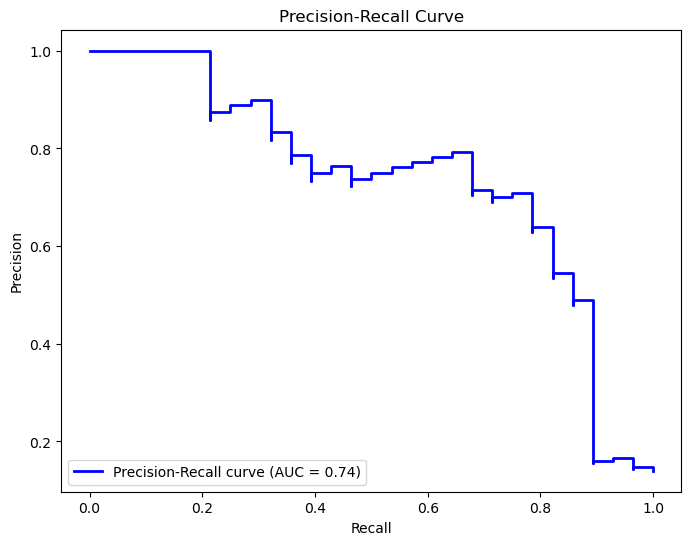

In [33]:
X_train, X_test = X[train_idx_svc], X[test_idx_svc]
Y_train, Y_test = Y[train_idx_svc], Y[test_idx_svc]

# ROC curve
decision_function = classifier2.decision_function(X_test)
fpr, tpr, _ = roc_curve(Y_test, decision_function)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(Y_test, decision_function)
pr_auc = average_precision_score(Y_test, decision_function)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', where='post', lw=2, label='Precision-Recall curve (AUC = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


---
**Task 11 (medium): ROC and Precision-Recall curves evaluation💡📽️**
1. Use the confusion matrix metrics to argue how the plots provide different insights into the classification model's ability to handle class imbalance? 
2. Describe when and why you would prioritize one curve over the other when dealing with imbalanced data.


---

In [0]:
#Write your reflections here...
# 1 Use the confusion matrix metrics to argue how the plots provide different insights into the classification model's ability to handle class imbalance? 

# Recall about Confusion matrix metrics:
    # Precision = TP / (TP + FP)
    # Recall/True Positive Rate (tpr) = TP / (TP + FN)
    # Flase Positive Rate (fpr) = FP / (FP + TN) = 1 − Specificity

# The ROC curve:
# "illustrates the trade-off between true positive rate (sensitivity) and false positive rate" 
# The true positive rate (TPR) is computed as TP / (TP + FN). (Same as recall).
# The false positive rate (FPR) is computed as FP / (FP + TN). (1 − Specificity).
# Combining these two rates, the ROC curve can give an overview across the different classifications, taking both TP, FN, FP, and TN into account.
# Problem: Imbalanced data with many true negatives (TN) makes FPR small (good) even if there are many false positive, so ROC/AUC can look good even if it is bad at predicting positive instances.
# In this specific case, the ROC curve gives an AUC value of 92% which indicates that the model has a good ability to distinguish between the positive and negative classes overall, 
# but this does not necessarily mean it performs well on predicting the positive class, which is the minority class.

# The Precision-Recall curve:
# "shows the balance between precision and recall."
# Precision is computed as TP / (TP + FP).
# Recall is computed as TP / (TP + FN).
# By combining these two metrices, the curve takes TP, FP and FN into account, but not TN. 
# Thereby it focuses on the positive class (in our case minority class) and how well the model identifies it.
# In this specific case, the Precision-Recall curve gives an AUC value of 69% which indicates that the model might not be very effective at identifying the positive class, even though the ROC curve suggested good overall performance.

# 2 Describe when and why you would prioritize one curve over the other when dealing with imbalanced data.

# The Prediction-Recall curve should be prioritized when 
# it is important to correctly identify the positive instances without too many false positives
# and the data is imbalanced (few positive instances).
# Examples:
# Disease screening (rare disease detection): catching true patients while avoiding many false alarms — prioritize high precision at acceptable recall. For example corona testing
# Search engine (information retrieval): want returned items to be relevant (precision) while retrieving enough results (recall).

# The ROC curve should be prioritized when
# the costs of false positives and false negatives are similar (equally important to predict positives and negatives correctly)
# and/or when the dataset is more balanced.
# Example:
# Medical test where false positives and false negatives have similar cost (e.g., general screening where follow‑up tests (confirmatory tests) are cheap)